# 第四节课实验：Res-PINN 与普通 PINN 对比（1D 热传导方程）

本 Notebook 目标：

1. 保持第三节的 PDE、初值条件、边界条件、采样规模和损失定义不变；
2. 用同一组超参数训练普通 PINN 与 Res-PINN；
3. 比较训练曲线、三项子损失、`L2 relative error` 和可视化结果；
4. 让学生看到：残差连接主要是在帮助优化，而不是改变物理问题本身。

## 1. 导入库与基础设置

In [1]:
import time
import copy
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

if torch.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Device:', device)

Device: mps


## 2. 问题定义与超参数

本节课保持第三节 case 不变：

$$
\frac{\partial u}{\partial t}=\alpha\frac{\partial^2 u}{\partial x^2},\quad x\in[0,1],\ t\in[0,1]
$$

$$
u(x,0)=\sin(\pi x),\quad u(0,t)=0,\quad u(1,t)=0
$$

In [14]:
alpha = 0.1

# 训练超参数：保持与第三节一致
N_ic = 500
N_bc = 500
N_f = 2000

hidden_dim = 64
num_hidden = 4
num_blocks = 4
lr = 1e-3
epochs = 5000

lambda_ic = 1.0
lambda_bc = 1.0
lambda_f = 1.0
dropout_rate = 0.1

print('N_ic =', N_ic)
print('N_bc =', N_bc)
print('N_f  =', N_f)
print('hidden_dim =', hidden_dim)
print('num_hidden =', num_hidden)
print('num_blocks =', num_blocks)
print('lr =', lr)
print('epochs =', epochs)
print('dropout_rate =', dropout_rate)

N_ic = 500
N_bc = 500
N_f  = 2000
hidden_dim = 64
num_hidden = 4
num_blocks = 4
lr = 0.001
epochs = 5000
dropout_rate = 0.1


## 3. 构造训练点（IC / BC / Collocation）

In [15]:
# IC: (x, 0)
x_ic = np.random.rand(N_ic, 1)
t_ic = np.zeros((N_ic, 1))
u_ic = np.sin(np.pi * x_ic)

# BC: (0, t) 和 (1, t)
t_bc = np.random.rand(N_bc, 1)
x_bc0 = np.zeros((N_bc, 1))
x_bc1 = np.ones((N_bc, 1))
u_bc0 = np.zeros((N_bc, 1))
u_bc1 = np.zeros((N_bc, 1))

# 内部 collocation 点
x_f = np.random.rand(N_f, 1)
t_f = np.random.rand(N_f, 1)


def to_tensor(a, requires_grad=False):
    return torch.tensor(a, dtype=torch.float32, device=device, requires_grad=requires_grad)


x_ic_t = to_tensor(x_ic)
t_ic_t = to_tensor(t_ic)
u_ic_t = to_tensor(u_ic)

x_bc0_t = to_tensor(x_bc0)
x_bc1_t = to_tensor(x_bc1)
t_bc_t = to_tensor(t_bc)
u_bc0_t = to_tensor(u_bc0)
u_bc1_t = to_tensor(u_bc1)

x_f_t = to_tensor(x_f, requires_grad=True)
t_f_t = to_tensor(t_f, requires_grad=True)

print('IC points:', x_ic_t.shape[0])
print('BC points:', x_bc0_t.shape[0] * 2)
print('F points :', x_f_t.shape[0])

IC points: 500
BC points: 1000
F points : 2000


## 4. 定义两种网络

普通 PINN：

$$
h^{(\ell+1)} = \sigma(W^{(\ell)} h^{(\ell)} + b^{(\ell)})
$$

Res-PINN：

$$
h^{(\ell+1)} = h^{(\ell)} + F^{(\ell)}(h^{(\ell)})
$$

In [16]:
class PINN(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden=4, dropout_rate=0.0):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))

        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))

        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)


class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim=64, dropout_rate=0.0):
        super().__init__()
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.act = nn.Tanh()
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else nn.Identity()

    def forward(self, x):
        residual = x
        out = self.act(self.fc1(x))
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.act(residual + out)
        return out


class ResPINN(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_blocks=4, dropout_rate=0.0):
        super().__init__()
        self.input_layer = nn.Linear(in_dim, hidden_dim)
        self.input_act = nn.Tanh()
        self.blocks = nn.ModuleList([
            ResidualBlock(hidden_dim, dropout_rate=dropout_rate) for _ in range(num_blocks)
        ])
        self.output_layer = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        h = self.input_act(self.input_layer(xt))
        for block in self.blocks:
            h = block(h)
        return self.output_layer(h)


baseline_model = PINN(hidden_dim=hidden_dim, num_hidden=num_hidden, dropout_rate=dropout_rate).to(device)
res_model = ResPINN(hidden_dim=hidden_dim, num_blocks=num_blocks, dropout_rate=dropout_rate).to(device)

print('Baseline PINN:')
print(baseline_model)
print('\nRes-PINN:')
print(res_model)

Baseline PINN:
PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Tanh()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): Tanh()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Dropout(p=0.1, inplace=False)
    (9): Linear(in_features=64, out_features=64, bias=True)
    (10): Tanh()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Res-PINN:
ResPINN(
  (input_layer): Linear(in_features=2, out_features=64, bias=True)
  (input_act): Tanh()
  (blocks): ModuleList(
    (0-3): 4 x ResidualBlock(
      (fc1): Linear(in_features=64, out_features=64, bias=True)
      (fc2): Linear(in_features=64, out_features=64, bias=True)
      (act): Tanh()
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=T

## 5. 自动微分与 PDE 残差

注意：这里的残差仍然是 PDE residual，而不是残差块。

In [18]:
def gradients(y, x):
    return torch.autograd.grad(
        y, x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True
    )[0]


def pde_residual(model, x, t, alpha):
    u = model(x, t)
    u_t = gradients(u, t)
    u_x = gradients(u, x)
    u_xx = gradients(u_x, x)
    return u_t - alpha * u_xx

## 6. 统一训练函数

为了做公平对比，我们让两种网络共享：

- 同一批训练点
- 同样的损失定义
- 同样的优化器
- 同样的学习率与训练轮数

In [20]:
def train_model(model, model_name, epochs=9000, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        'total': [],
        'ic': [],
        'bc': [],
        'f': [],
    }

    start = time.time()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        u_ic_pred = model(x_ic_t, t_ic_t)
        loss_ic = torch.mean((u_ic_pred - u_ic_t) ** 2)

        u_bc0_pred = model(x_bc0_t, t_bc_t)
        u_bc1_pred = model(x_bc1_t, t_bc_t)
        loss_bc = torch.mean((u_bc0_pred - u_bc0_t) ** 2) + torch.mean((u_bc1_pred - u_bc1_t) ** 2)

        f = pde_residual(model, x_f_t, t_f_t, alpha)
        loss_f = torch.mean(f ** 2)

        loss = lambda_ic * loss_ic + lambda_bc * loss_bc + lambda_f * loss_f
        loss.backward()
        optimizer.step()

        history['total'].append(loss.item())
        history['ic'].append(loss_ic.item())
        history['bc'].append(loss_bc.item())
        history['f'].append(loss_f.item())

        if epoch % 1000 == 0 or epoch == 1:
            print(
                f'[{model_name}] Epoch {epoch:4d} | '
                f'Total {loss.item():.4e} | '
                f'IC {loss_ic.item():.4e} | '
                f'BC {loss_bc.item():.4e} | '
                f'PDE {loss_f.item():.4e}'
            )

    elapsed = time.time() - start
    print(f'[{model_name}] Training done in {elapsed:.2f} s')
    return history, elapsed

## 7. 开始训练

如果课堂时间紧张，可以先只跑 `Res-PINN`，但论文式对比更推荐两者都跑。

In [21]:
baseline_history, baseline_time = train_model(
    baseline_model,
    model_name='PINN',
    epochs=epochs,
    lr=lr,
)

res_history, res_time = train_model(
    res_model,
    model_name='ResPINN',
    epochs=epochs,
    lr=lr,
)

[PINN] Epoch    1 | Total 4.2754e-01 | IC 4.0379e-01 | BC 2.2829e-02 | PDE 9.2312e-04
[PINN] Epoch 1000 | Total 2.2856e-02 | IC 7.3953e-03 | BC 7.1386e-03 | PDE 8.3217e-03
[PINN] Epoch 2000 | Total 1.9150e-02 | IC 6.0232e-03 | BC 6.0377e-03 | PDE 7.0889e-03
[PINN] Epoch 3000 | Total 1.7203e-02 | IC 5.7090e-03 | BC 4.8972e-03 | PDE 6.5967e-03
[PINN] Epoch 4000 | Total 1.5605e-02 | IC 5.2486e-03 | BC 4.5962e-03 | PDE 5.7602e-03
[PINN] Epoch 5000 | Total 1.5911e-02 | IC 5.5624e-03 | BC 4.3856e-03 | PDE 5.9631e-03
[PINN] Training done in 77.67 s
[ResPINN] Epoch    1 | Total 1.3013e+00 | IC 1.0750e+00 | BC 2.1774e-01 | PDE 8.5036e-03
[ResPINN] Epoch 1000 | Total 1.5449e-03 | IC 4.8163e-04 | BC 3.1288e-04 | PDE 7.5043e-04
[ResPINN] Epoch 2000 | Total 6.9215e-04 | IC 2.0791e-04 | BC 1.7857e-04 | PDE 3.0568e-04
[ResPINN] Epoch 3000 | Total 6.3216e-04 | IC 1.9664e-04 | BC 2.6148e-04 | PDE 1.7404e-04
[ResPINN] Epoch 4000 | Total 2.9259e-04 | IC 6.5604e-05 | BC 1.0546e-04 | PDE 1.2153e-04
[ResPIN

## 8. 训练曲线对比

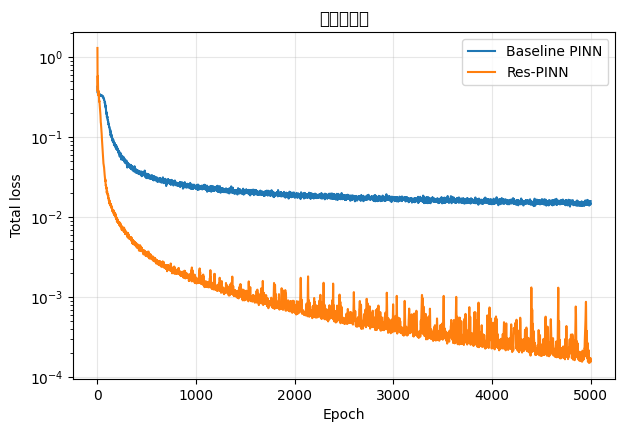

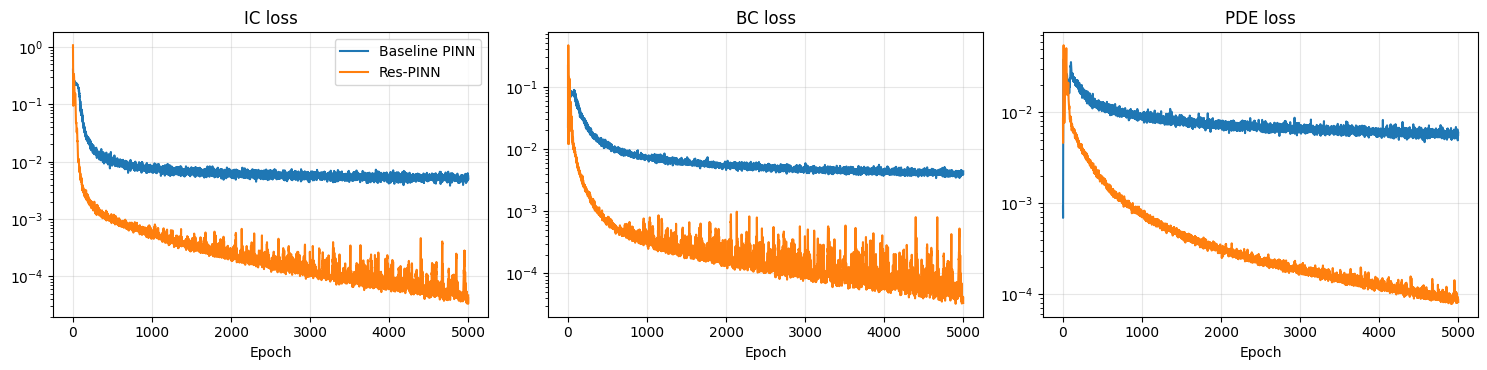

In [22]:
plt.figure(figsize=(7, 4.5))
plt.semilogy(baseline_history['total'], label='Baseline PINN')
plt.semilogy(res_history['total'], label='Res-PINN')
plt.xlabel('Epoch')
plt.ylabel('Total loss')
plt.title('总损失对比')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, key, title in zip(axes, ['ic', 'bc', 'f'], ['IC loss', 'BC loss', 'PDE loss']):
    ax.semilogy(baseline_history[key], label='Baseline PINN')
    ax.semilogy(res_history[key], label='Res-PINN')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()

## 9. 网格评估与误差指标

In [23]:
def exact_solution(x, t, alpha):
    return np.exp(-alpha * np.pi**2 * t) * np.sin(np.pi * x)


def evaluate_model(model, alpha, nx=200, nt=200):
    x_eval = np.linspace(0, 1, nx)
    t_eval = np.linspace(0, 1, nt)
    X, T = np.meshgrid(x_eval, t_eval)
    XT = np.hstack([X.reshape(-1, 1), T.reshape(-1, 1)])

    xt_tensor = torch.tensor(XT, dtype=torch.float32, device=device)
    model.eval()
    with torch.no_grad():
        u_pred = model(xt_tensor[:, :1], xt_tensor[:, 1:2]).cpu().numpy().reshape(nt, nx)
    model.train()

    u_exact = exact_solution(X, T, alpha)
    abs_err = np.abs(u_pred - u_exact)
    l2_rel = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)

    return {
        'x_eval': x_eval,
        't_eval': t_eval,
        'X': X,
        'T': T,
        'u_pred': u_pred,
        'u_exact': u_exact,
        'abs_err': abs_err,
        'l2_rel': l2_rel,
    }


baseline_eval = evaluate_model(baseline_model, alpha)
res_eval = evaluate_model(res_model, alpha)

print(f"Baseline PINN L2 relative error: {baseline_eval['l2_rel']:.4e}")
print(f"Res-PINN      L2 relative error: {res_eval['l2_rel']:.4e}")
print(f'Baseline training time: {baseline_time:.2f} s')
print(f'Res-PINN training time: {res_time:.2f} s')

Baseline PINN L2 relative error: 1.9922e-02
Res-PINN      L2 relative error: 3.5931e-03
Baseline training time: 77.67 s
Res-PINN training time: 136.10 s


## 10. 三张核心图：普通 PINN

/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/2461060647.py:21: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/2461060647.py:21: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/2461060647.py:21: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/2461060647.py:21: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/2461060647.py:21: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/cptbdjgx7

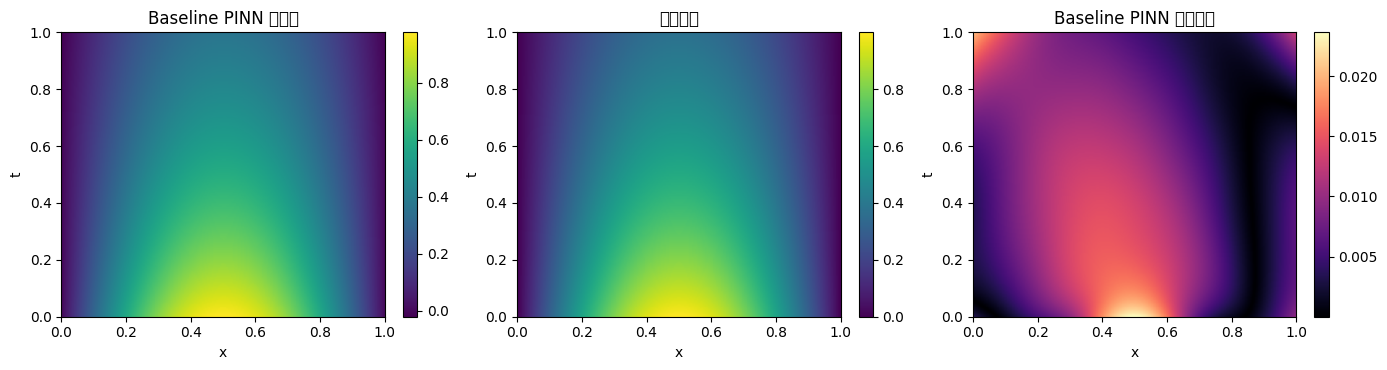

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

im0 = axes[0].imshow(baseline_eval['u_pred'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axes[0].set_title('Baseline PINN 预测解')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(baseline_eval['u_exact'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axes[1].set_title('解析真解')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(baseline_eval['abs_err'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='magma')
axes[2].set_title('Baseline PINN 绝对误差')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

## 11. 三张核心图：Res-PINN

/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/893609570.py:21: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/893609570.py:21: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/893609570.py:21: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/893609570.py:21: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/893609570.py:21: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/cptbdjgx7q99mn

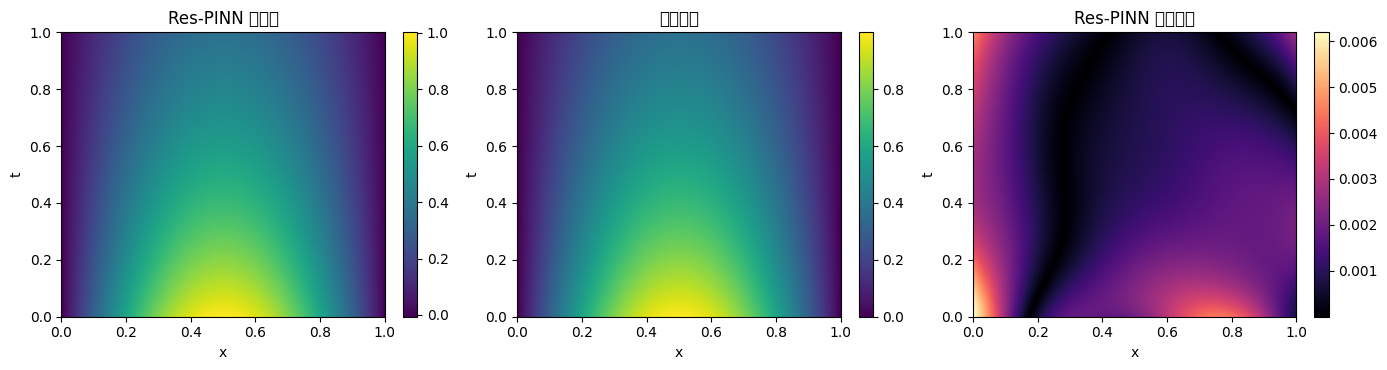

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

im0 = axes[0].imshow(res_eval['u_pred'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axes[0].set_title('Res-PINN 预测解')
axes[0].set_xlabel('x')
axes[0].set_ylabel('t')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(res_eval['u_exact'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
axes[1].set_title('解析真解')
axes[1].set_xlabel('x')
axes[1].set_ylabel('t')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(res_eval['abs_err'], extent=[0,1,0,1], origin='lower', aspect='auto', cmap='magma')
axes[2].set_title('Res-PINN 绝对误差')
axes[2].set_xlabel('x')
axes[2].set_ylabel('t')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

## 12. 时间切片对比图

/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/1329326183.py:18: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/45/cptbdjgx7q99mnz2lv310c9m0000gn/T/ipykernel_7942/1329326183.py:18: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


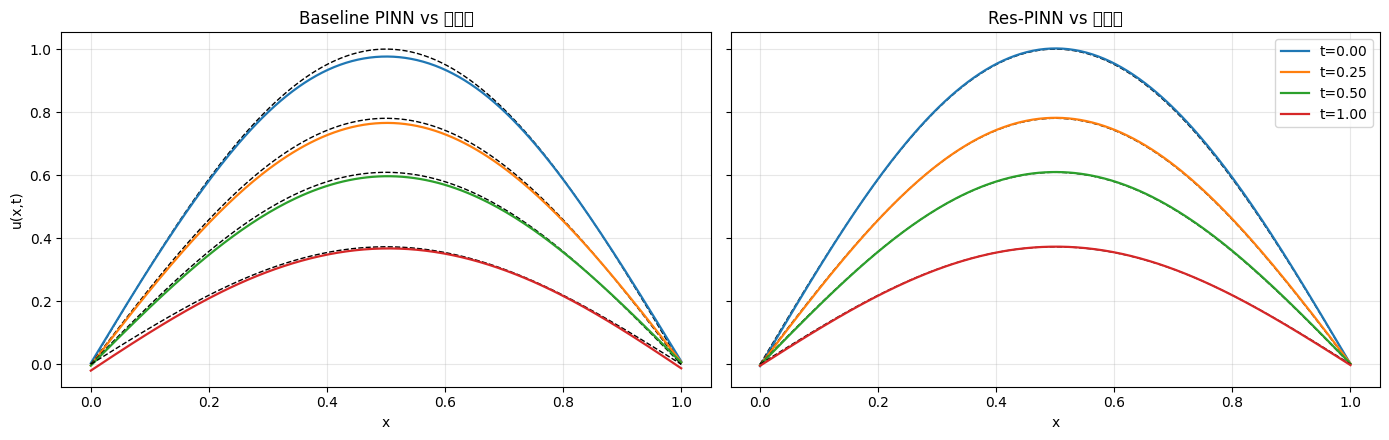

In [26]:
time_slices = [0.0, 0.25, 0.5, 1.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for ax, title, result in [
    (axes[0], 'Baseline PINN vs 解析解', baseline_eval),
    (axes[1], 'Res-PINN vs 解析解', res_eval),
]:
    for ts in time_slices:
        idx = np.argmin(np.abs(result['t_eval'] - ts))
        ax.plot(result['x_eval'], result['u_exact'][idx], 'k--', linewidth=1.0)
        ax.plot(result['x_eval'], result['u_pred'][idx], linewidth=1.6, label=f't={result["t_eval"][idx]:.2f}')
    ax.set_xlabel('x')
    ax.set_title(title)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('u(x,t)')
axes[1].legend()
plt.tight_layout()
plt.show()

## 13. 结果汇总表

In [27]:
summary = {
    'Baseline PINN': {
        'final_total_loss': baseline_history['total'][-1],
        'final_ic_loss': baseline_history['ic'][-1],
        'final_bc_loss': baseline_history['bc'][-1],
        'final_pde_loss': baseline_history['f'][-1],
        'l2_relative_error': baseline_eval['l2_rel'],
        'train_time_s': baseline_time,
    },
    'Res-PINN': {
        'final_total_loss': res_history['total'][-1],
        'final_ic_loss': res_history['ic'][-1],
        'final_bc_loss': res_history['bc'][-1],
        'final_pde_loss': res_history['f'][-1],
        'l2_relative_error': res_eval['l2_rel'],
        'train_time_s': res_time,
    },
}

for name, info in summary.items():
    print(name)
    for key, value in info.items():
        print(f'  {key:18s}: {value:.4e}' if isinstance(value, float) else f'  {key}: {value}')
    print()

Baseline PINN
  final_total_loss  : 1.5911e-02
  final_ic_loss     : 5.5624e-03
  final_bc_loss     : 4.3856e-03
  final_pde_loss    : 5.9631e-03
  l2_relative_error : 1.9922e-02
  train_time_s      : 7.7670e+01

Res-PINN
  final_total_loss  : 1.6287e-04
  final_ic_loss     : 4.6882e-05
  final_bc_loss     : 3.3583e-05
  final_pde_loss    : 8.2401e-05
  l2_relative_error : 3.5931e-03
  train_time_s      : 1.3610e+02



## 14. 课堂讨论建议

1. 如果 `Res-PINN` 的总 loss 更快下降，它主要改善的是哪一项？
2. 如果 `Res-PINN` 的总 loss 更小，但 `L2 relative error` 没明显改善，说明什么？
3. 如果普通 PINN 加深后变难训，而 Res-PINN 更稳，这是否支持“残差连接改善优化”的判断？
4. 这个 1D 热传导问题本身并不算很难，若差异不夸张，是否合理？